In [ ]:
# -- mount if not already --
import os

if os.path.exists('/content/drive/MyDrive'):
    print('Google Drive already mounted')
else:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)


In [ ]:
!unzip /content/drive/MyDrive/UPF_Thesis/Geolife_Trajectories.zip -d /content/Geolife_Trajectories

In [ ]:
BEIJING_BBOX = {
    "lat_min": 39.4,
    "lat_max": 41.6,
    "lon_min": 115.7,
    "lon_max": 117.4
}
def filter_beijing_bbox(df, lat_col='lat', lon_col='lon'):
    return df[
        (df[lat_col] >= 39.4) & (df[lat_col] <= 41.6) &
        (df[lon_col] >= 115.7) & (df[lon_col] <= 117.4)
    ]

In [ ]:
import numpy as np
import pandas as pd

def haversine_distance(lat1, lon1, lat2, lon2, metric='m'):
    """
    Vectorized haversine distance.
    """
    R = 6371000.0  # meters

    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    d = 2 * R * np.arcsin(np.sqrt(a))

    if metric == 'm':
        return d
    elif metric == 'km':
        return d / 1000.0
    else:
        raise ValueError("metric must be 'm' or 'km'")


def segment_geolife_sessions_dwell(
    df,
    session_col='session_id',
    user_col='user_id',
    time_col='datetime',
    lat_col='lat',
    lon_col='lon',
    gap_minutes=30,
    centroid_window='4min',
    min_points_in_window=5, # if 5 points in 4 min window then check dwell logic
    dwell_radius_m=100,
    dwell_minutes=20,

):
    """
    Segment each session using:
      1. big time gaps
      2. dwell detection based on distance to a rolling centroid

    Returns the original rows plus:
      - time_diff_sec
      - centroid_lat / centroid_lon
      - dist_to_centroid_m
      - in_dwell_radius
      - dwell_block
      - dwell_duration_sec
      - split_big_gap
      - split_long_dwell
      - new_segment
      - segment_id
      - trip_id
    """

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])

    sort_cols = [session_col, time_col]
    if user_col in df.columns:
        sort_cols = [user_col] + sort_cols

    df = df.sort_values(sort_cols).reset_index(drop=True)

    gap_sec = gap_minutes * 60
    dwell_sec = dwell_minutes * 60

    def process_one_session(g):
        g = g.sort_values(time_col).copy()

        # time gap
        g['time_diff_sec'] = g[time_col].diff().dt.total_seconds()

        # rolling centroid over the last X minutes
        # use time-aware rolling window
        temp = g.set_index(time_col)

        rolling_obj = temp[[lat_col, lon_col]].rolling(centroid_window, min_periods=min_points_in_window)

        temp['centroid_lat'] = rolling_obj[lat_col].mean()
        temp['centroid_lon'] = rolling_obj[lon_col].mean()

        # optional count in window, useful for debugging
        temp['points_in_centroid_window'] = rolling_obj[lat_col].count()

        g = temp.reset_index()

        # distance from current point to rolling centroid
        valid_centroid = g['centroid_lat'].notna() & g['centroid_lon'].notna()

        g['dist_to_centroid_m'] = np.nan
        g.loc[valid_centroid, 'dist_to_centroid_m'] = haversine_distance(
            g.loc[valid_centroid, lat_col],
            g.loc[valid_centroid, lon_col],
            g.loc[valid_centroid, 'centroid_lat'],
            g.loc[valid_centroid, 'centroid_lon'],
            metric='m'
        )

        # inside dwell radius
        g['in_dwell_radius'] = g['dist_to_centroid_m'] <= dwell_radius_m
        g['in_dwell_radius'] = g['in_dwell_radius'].fillna(False)

        # big gap split
        g['split_big_gap'] = g['time_diff_sec'] > gap_sec

        # new dwell block whenever dwell-state changes OR a big gap happens
        state_change = g['in_dwell_radius'] != g['in_dwell_radius'].shift(fill_value=False)
        gap_change = g['split_big_gap'].fillna(False)

        g['dwell_block'] = (state_change | gap_change).cumsum()

        # accumulate time only while inside dwell radius
        g['dwell_time_add'] = np.where(
            g['in_dwell_radius'],
            g['time_diff_sec'].fillna(0),
            0
        )

        g['dwell_duration_sec'] = (
            g.groupby('dwell_block')['dwell_time_add']
             .cumsum()
        )

        # split exactly when dwell block first crosses threshold
        prev_dwell = g.groupby('dwell_block')['dwell_duration_sec'].shift(fill_value=0)

        g['split_long_dwell'] = (
            g['in_dwell_radius'] &
            (g['dwell_duration_sec'] >= dwell_sec) &
            (prev_dwell < dwell_sec)
        )

        # new segment starts at:
        # - first row
        # - big gap
        # - first row crossing long dwell threshold
        g['new_segment'] = False
        g.loc[g.index[0], 'new_segment'] = True
        g['new_segment'] = g['new_segment'] | g['split_big_gap'] | g['split_long_dwell']

        g['segment_id'] = g['new_segment'].cumsum()

        if user_col in g.columns:
            g['trip_id'] = (
                g[user_col].astype(str) + '_' +
                g[session_col].astype(str) + '_' +
                g['segment_id'].astype(str)
            )
        else:
            g['trip_id'] = (
                g[session_col].astype(str) + '_' +
                g['segment_id'].astype(str)
            )

        return g

    group_cols = [session_col]
    if user_col in df.columns:
        group_cols = [user_col, session_col]

    #out = (
    #    df.groupby(group_cols, group_keys=False)
    #      .apply(process_one_session, include_groups)
    #      .reset_index(drop=True)
    #)

    out = []
    for keys, g in df.groupby(group_cols):
        out.append(process_one_session(g))

    out = pd.concat(out, ignore_index=True)

    return out




# Data Import

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/UPF_Thesis/gadm41_CHN_1.json.zip"
extract_dir = "/content/gadm_beijing"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))

In [ ]:
import geopandas as gpd
geojson_path = "/content/gadm_beijing/gadm41_CHN_1.json"
gadm_lvl1 = gpd.read_file(geojson_path)
beijing = gadm_lvl1[gadm_lvl1["NAME_1"] == "Beijing"]
print(beijing[["NAME_1"]])
print("Number of Beijing polygons:", len(beijing))

In [ ]:
pip install h3

In [ ]:
import pandas as pd
import h3


def to_od_grid(
    df_seg,
    grid_resolution=6,
    drop_same_hex=True,
    min_duration_minutes=5,
    boundary_filter=beijing,
    keep_mode_strategy="middle",   # "middle", "first", "mode"
    verbose=False,
):
    """
    Convert segmented trajectory points into OD hex-grid trips.

    """


    required_cols = ["datetime", "lat", "lon", "trip_id", "user_id", "session_id"]
    missing = [c for c in required_cols if c not in df_seg.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    cols_to_keep = required_cols.copy()
    has_mode = "mode" in df_seg.columns
    if has_mode:
        cols_to_keep.append("mode")

    df = df_seg[cols_to_keep].copy()
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    # Drop rows with missing essentials
    df = df.dropna(subset=["datetime", "lat", "lon", "trip_id", "user_id", "session_id"])

    if df.empty:
        raise ValueError("No valid rows left after dropping missing required values.")

    # Sort before assigning OD
    df = df.sort_values(["trip_id", "datetime"]).reset_index(drop=True)

    # Convert points to H3 hex cells
    df["hex_id"] = df.apply(
        lambda row: h3.latlng_to_cell(row["lat"], row["lon"], grid_resolution),
        axis=1
    )


    if boundary_filter is not None:
        df_g = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df["lon"], df["lat"]),
            crs="EPSG:4326")
        beijing_geom = boundary_filter.union_all()
        df['in_beijing'] = df_g.within(beijing_geom)


    def summarize_mode(g):
        if not has_mode:
            return None

        mode_series = g["mode"].dropna()
        if mode_series.empty:
            return None

        if keep_mode_strategy == "middle":
            valid = g[g["mode"].notna()]
            return valid.iloc[len(valid) // 2]["mode"]
        elif keep_mode_strategy == "first":
            return mode_series.iloc[0]
        elif keep_mode_strategy == "mode":
            return mode_series.mode().iloc[0]
        else:
            raise ValueError("keep_mode_strategy must be one of: 'middle', 'first', 'mode'")

    od_rows = []

    for trip_id, g in df.groupby("trip_id", sort=False):

        #completely skips trip if any cordinate is outside beijing
        if boundary_filter is not None and not g["in_beijing"].all():
            continue

        g = g.sort_values("datetime")

        first_row = g.iloc[0]
        last_row = g.iloc[-1]
        start_hex = first_row["hex_id"]
        end_hex = last_row["hex_id"]




        od_depart_time = g.loc[g["hex_id"] == start_hex, "datetime"].max()
        od_arrive_time = g.loc[g["hex_id"] == end_hex, "datetime"].min()
        od_duration_minutes = (od_arrive_time - od_depart_time).total_seconds() / 60.0
        if od_arrive_time < od_depart_time:
            continue

        #segment_start_time = first_row["datetime"]
        #segment_end_time = last_row["datetime"]
        #segment_duration_minutes = (segment_end_time - segment_start_time).total_seconds() / 60.0

        hex_num_points = g['hex_id'].nunique()
        g['datetime_diff'] = g['datetime'].diff().dt.total_seconds()
        avg_gps_splits = g['datetime_diff'].mean()

        traj_dist_m = haversine_distance(
            first_row["lat"],
            first_row["lon"],
            last_row["lat"],
            last_row["lon"],
            metric="m"
        )

        od_row = {
            "trip_id": trip_id,
            "user_id": first_row["user_id"],
            "session_id": first_row["session_id"],
            "start_time": od_depart_time,
            "end_time": od_arrive_time,
            "duration_minutes": od_duration_minutes,
            "start_hex": first_row["hex_id"],
            "end_hex": last_row["hex_id"],
            "n_points": len(g),
            "inter_hex_num":max(0, hex_num_points - 2),
            "avg_gps_splits": avg_gps_splits,
            "traj_start_lat": first_row["lat"],
            "traj_start_lon": first_row["lon"],
            "traj_end_lat": last_row["lat"],
            "traj_end_lon": last_row["lon"],
            "traj_dist_m": traj_dist_m,
        }

        if has_mode:
            od_row["mode"] = summarize_mode(g)

        od_rows.append(od_row)

    od_trips = pd.DataFrame(od_rows)

    if od_trips.empty:
        return od_trips


    # Optional same-cell drop
    before = len(od_trips)
    if drop_same_hex:
        before = len(od_trips)
        od_trips = od_trips[od_trips["start_hex"] != od_trips["end_hex"]].copy()
        if verbose:
            dropped = before - len(od_trips)
            perc_dropped = 0.0 if before == 0 else 100 * dropped / before
            print(f"Dropped same-hex trips: {dropped} ({perc_dropped:.1f}%)")

    # Optional minimum duration filter
    if min_duration_minutes is not None:
        before = len(od_trips)
        od_trips = od_trips[od_trips["duration_minutes"] >= min_duration_minutes].copy()
        if verbose:
            dropped = before - len(od_trips)
            perc_dropped = 0.0 if before == 0 else 100 * dropped / before
            print(f"Dropped due to minimum duration: {dropped} ({perc_dropped:.1f}%)")

    if verbose:
        print(f'{len(od_trips)} trips')
        print(f'across {od_trips["user_id"].nunique()} users')
        print(f'across {od_trips["session_id"].nunique()} sessions')

        all_hex = set(od_trips['start_hex']) | set(od_trips['end_hex'])
        print(f'across {len(all_hex)} hex cells')

        print(f'avg duration: {od_trips["duration_minutes"].mean():.1f} min')


    return od_trips



'''
od_trips = to_od_grid(
    df_seg,
    grid_resolution=6,
    drop_same_hex=True,
    min_duration_minutes=12,
    boundary_filter=beijing,
    keep_mode_strategy="middle",   # "middle", "first", "mode"
    verbose=True
)

od_trips.head()
'''

In [ ]:
import os
import pandas as pd
import numpy as np
import gc
from tqdm import tqdm


base_path = "/content/Geolife_Trajectories/Geolife Trajectories 1.3/Data"


users = sorted(os.listdir(base_path))  # all users
len(users)


od_trips = pd.DataFrame([])
pbar = tqdm(users[2:23], desc="Processing users...")
for user in pbar:
    user_path = os.path.join(base_path, user, "Trajectory")


    # get tranport labels if applicable
    labels_df = None
    labels_path = os.path.join(base_path, user, "labels.txt")
    if os.path.exists(labels_path):
        try:
            print(f"User {user} has labels")
            labels_df = pd.read_csv(labels_path, sep='\t')
            labels_df['Start Time'] = pd.to_datetime(labels_df['Start Time'])
            labels_df['End Time'] = pd.to_datetime(labels_df['End Time'])
            labels_df['Transportation Mode'] = labels_df['Transportation Mode'].astype(str)
        except:
            raise ValueError(f"Error Reading label.text for {user}")


    df_user = pd.DataFrame([])
    for file in os.listdir(user_path):
        if not file.endswith(".plt"):
            continue

        file_path = os.path.join(user_path, file)

        try:
            # Load just one session file
            df_session = pd.read_csv(
                file_path, skiprows=6, header=None,
                names=[
                    "lat", "lon", "unused", "altitude",
                    "date_days", "date", "time"
                ])


            # Keep only needed columns
            df_session = df_session[["lat", "lon", "date", "time","altitude"]].copy()
            df_session["datetime"] = pd.to_datetime(df_session["date"] + " " + df_session["time"])

            # Sort just in case
            df_session = df_session.sort_values("datetime").reset_index(drop=True)

            if df_session.empty:
                continue


            #apply transport lables if applicable
            df_session['mode'] = None  # optional but clean
            if labels_df is not None:
                for _, row in labels_df.iterrows():
                    df_session.loc[
                        (df_session['datetime'] >= row['Start Time']) &
                        (df_session['datetime'] <= row['End Time']),
                        'mode'
                    ] = row['Transportation Mode']

            #append user data
            df_session['user_id'] = user.strip()
            df_session['session_id'] = file.strip()[:-4]






            df_user = pd.concat([df_user, df_session], ignore_index=True)


        except Exception as e:
            print(f"Error on user {user} reading {file_path}: {e}")

    df_seg_user = segment_geolife_sessions_dwell(df_user)
    od_trips_user = to_od_grid(df_seg_user)
    od_trips = pd.concat([od_trips, od_trips_user], ignore_index=True)
    total_trips = len(od_trips)
    pbar.set_postfix({"total_trips": total_trips})

    del df_user
    del df_seg_user
    del od_trips_user
    #print(f"Finished user {user}")

print("Final shape:", od_trips.shape)
od_trips.head()

In [ ]:
import os
import json
import pandas as pd
from datetime import datetime, timezone

def load_processed_users(checkpoint_path):
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            return json.load(f)
    return {}

def save_processed_users(processed_users, checkpoint_path):
    with open(checkpoint_path, "w") as f:
        json.dump(processed_users, f, indent=2)

def append_df_to_csv(df, csv_path):
    if df is None or df.empty:
        return
    file_exists = os.path.exists(csv_path)
    df.to_csv(csv_path, mode="a", header=not file_exists, index=False)

def summarize_user_trips(od_trips_user, df_user=None):
    processed_at = datetime.now(timezone.utc).isoformat()

    if od_trips_user is None or od_trips_user.empty:
        return {
            "n_trips": 0,
            "avg_duration_minutes": None,
            "avg_gps_split_seconds": None,
            "avg_trip_distance_km": None,
            "n_points": int(len(df_user)) if df_user is not None else 0,
            "processed_at": processed_at
        }

    return {
        "n_trips": int(len(od_trips_user)),
        "avg_duration_minutes": float(od_trips_user["duration_minutes"].mean()),
        "avg_gps_split": float(od_trips_user["avg_gps_split"].mean()) if "avg_gps_split" in od_trips_user.columns else None,
        "avg_trip_dist_km": float(od_trips_user["traj_dist_m"].mean()/ 1000.0) if "traj_dist_m" in od_trips_user.columns else None,
        "n_points": int(len(df_user)) if df_user is not None else None,
        "processed_at": processed_at
    }

In [ ]:
drive_dir = "/content/drive/MyDrive/UPF_Thesis/data"
os.makedirs(drive_dir, exist_ok=True)

data_path = os.path.join(drive_dir, "od_trips_20260410.csv")
checkpoint_path = os.path.join(drive_dir, "processed_users_20260410.json")

processed_users = load_processed_users(checkpoint_path)

In [ ]:
# RUN CODE

pbar = tqdm(users[:], desc="Processing users...")

for user in pbar:
    if str(user) in processed_users:
        print(f"Skipping user {user}: already processed.")
        continue

    user_path = os.path.join(base_path, user, "Trajectory")
    labels_df = None
    labels_path = os.path.join(base_path, user, "labels.txt")

    if os.path.exists(labels_path):
        try:
            #print(f"User {user} has labels")
            labels_df = pd.read_csv(labels_path, sep='\t')
            labels_df['Start Time'] = pd.to_datetime(labels_df['Start Time'])
            labels_df['End Time'] = pd.to_datetime(labels_df['End Time'])
            labels_df['Transportation Mode'] = labels_df['Transportation Mode'].astype(str)
        except Exception as e:
            raise ValueError(f"Error reading labels.txt for {user}: {e}")

    df_user = pd.DataFrame([])

    for file in os.listdir(user_path):
        if not file.endswith(".plt"):
            continue

        file_path = os.path.join(user_path, file)

        try:
            df_session = pd.read_csv(
                file_path,
                skiprows=6,
                header=None,
                names=["lat", "lon", "unused", "altitude", "date_days", "date", "time"]
            )

            df_session = df_session[["lat", "lon", "date", "time", "altitude"]].copy()
            df_session["datetime"] = pd.to_datetime(df_session["date"] + " " + df_session["time"])
            df_session = df_session.sort_values("datetime").reset_index(drop=True)

            if df_session.empty:
                continue

            df_session["mode"] = None

            if labels_df is not None:
                for _, row in labels_df.iterrows():
                    df_session.loc[
                        (df_session["datetime"] >= row["Start Time"]) &
                        (df_session["datetime"] <= row["End Time"]),
                        "mode"
                    ] = row["Transportation Mode"]

            df_session["user_id"] = user.strip()
            df_session["session_id"] = file.strip()[:-4]

            df_user = pd.concat([df_user, df_session], ignore_index=True)

        except Exception as e:
            print(f"Error on user {user} reading {file_path}: {e}")

    if df_user.empty:
        print(f"No valid data for user {user}, skipping.")
        processed_users[str(user)] = {
            "n_trips": 0,
            "avg_duration_minutes": None
        }
        save_processed_users(processed_users, checkpoint_path)
        continue

    df_seg_user = segment_geolife_sessions_dwell(df_user)
    od_trips_user = to_od_grid(df_seg_user)

    append_df_to_csv(od_trips_user, data_path)

    processed_users[str(user)] = summarize_user_trips(od_trips_user, df_user=df_user)
    save_processed_users(processed_users, checkpoint_path)

    pbar.set_postfix({
        "saved_users": len(processed_users),
        "last_user_trips": processed_users[str(user)]["n_trips"]
    })

    del df_user
    del df_seg_user
    del od_trips_user

Yes. The easiest route is usually one of these two:

1. Square grid in projected meters with geopandas + shapely + pyproj
2. Hex grid with h3-py

sweet spot is 200m-500m grids


For your use case, Beijing OD trips, I would usually pick square grid in meters first, because it is simple, interpretable, and easy to explain in a thesis. If you want a more elegant spatial partition, h3-py is excellent and has a direct latlng_to_cell(lat, lng, res) function. GeoPandas supports point creation and spatial joins, which is handy if you build your own grid

In [ ]:
looking = pd.DataFrame(processed_users).T
looking

In [ ]:
print(looking.sum())
looking.describe()

In [ ]:
output_file_path = '/content/drive/MyDrive/UPF_Thesis/data/od_trips_20260410.csv'
all_trips_df = pd.read_csv(output_file_path)
all_trips_df.head()

In [ ]:
len(all_trips_df)

In [ ]:

all_hexs_counts = pd.DataFrame([all_trips_df['start_hex'], all_trips_df['end_hex']])
all_hexs_counts.value_counts()

In [ ]:
all_hexs = set(all_trips_df['start_hex']) | set(all_trips_df['end_hex'])
print(len(all_hexs))

In [ ]:
all_trips_df.describe()

In [ ]:
import folium
import h3

def plot_h3_cells(cell_ids, zoom_start=11):
    # center map on average of cell centers
    centers = [h3.cell_to_latlng(h) for h in cell_ids]
    center_lat = sum(lat for lat, lng in centers) / len(centers)
    center_lng = sum(lng for lat, lng in centers) / len(centers)

    m = folium.Map(location=[center_lat, center_lng], zoom_start=zoom_start)

    for h in cell_ids:
        boundary = h3.cell_to_boundary(h)  # returns [(lat, lng), ...]
        folium.Polygon(
            locations=boundary,
            weight=1,
            fill=True,
            fill_opacity=0.3,
            popup=str(h)
        ).add_to(m)

    return m

In [ ]:
all_hex = list(set(all_trips_df['start_hex']) | set(all_trips_df['end_hex']))
len(all_hex)

m = plot_h3_cells(all_hex, zoom_start=12)
m

In [ ]:
od_trips.describe()

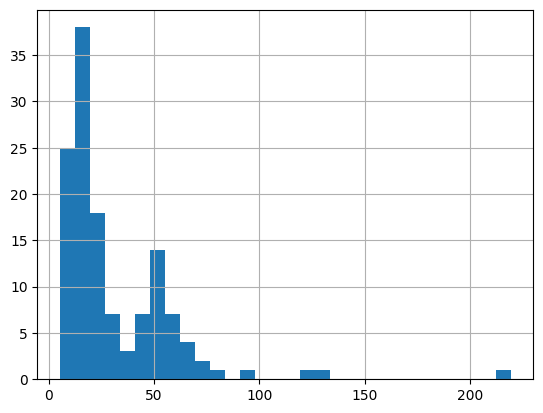

In [ ]:
od_trips['duration_minutes'].hist(bins = 30)

In [ ]:
import pandas as pd
import folium

def plot_points_fraction_map(
    df,
    lat_col='lat',
    lon_col='lon',
    frac=0.01,
    random_state=42,
    max_points=None,
    zoom_start=11
):
    # Keep only valid coordinates
    plot_df = df[[lat_col, lon_col]].dropna().copy()
    plot_df = plot_df[
        plot_df[lat_col].between(-90, 90) &
        plot_df[lon_col].between(-180, 180)
    ]

    if plot_df.empty:
        raise ValueError("No valid latitude/longitude points to plot.")

    # Sample a fraction
    if frac < 1.0:
        plot_df = plot_df.sample(frac=frac, random_state=random_state)

    # Optional hard cap
    if max_points is not None and len(plot_df) > max_points:
        plot_df = plot_df.sample(n=max_points, random_state=random_state)

    if plot_df.empty:
        raise ValueError("Sampling produced no points. Try a larger frac.")

    # Center map on sampled points
    center_lat = plot_df[lat_col].mean()
    center_lon = plot_df[lon_col].mean()

    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start)

    # Add points
    for _, row in plot_df.iterrows():
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=2,
            fill=True,
            fill_opacity=0.7
        ).add_to(m)

    return m

df_beijing = filter_beijing_bbox(df)
m = plot_points_fraction_map(df_beijing, frac=0.05)#, max_points=5000)
m

In [ ]:
# Define buckets
bucket_counts = {
    "<2 days": (days_per_user < 2).sum(),
    "2-10 days": ((days_per_user >= 2) & (days_per_user <= 10)).sum(),
    "10+ days": (days_per_user > 10).sum()
}

print(bucket_counts)

# Create bucket labels
buckets = pd.cut(
    days_per_user,
    bins=[0, 2, 10, float('inf')],
    labels=["<2 days", "2-10 days", "10+ days"],
    right=False  # makes intervals [0,2), [2,10), [10,∞)
)


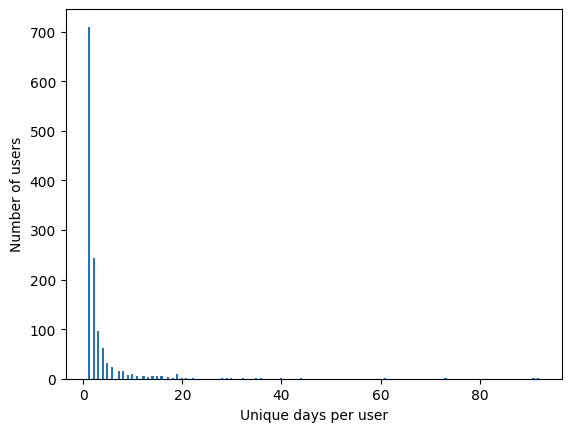

In [ ]:
import matplotlib.pyplot as plt

plt.hist(days_per_user, bins=200)
plt.xlabel("Unique days per user")
plt.ylabel("Number of users")
plt.show()

In [ ]:
# summary statics of OD
# document what i did (methodology, justify)
# state what modes
# do first half of report: by end of April!
# urban transitions 2026 (in sidges in November, new conference) 8th of May

# in two weeks:
# abstract: hypothesis.
# dataset description (summary/modes), majority of methodology with justifications (what was done so far)
# train one model (less of priority)

# Feature Engineering

In [ ]:
all_trips_df

In [ ]:
all_trips_df[['start_centroid_lat', 'start_centroid_lon']] = (
    all_trips_df['start_hex']
    .apply(lambda h: pd.Series(h3.cell_to_latlng(h)))
)

all_trips_df[['end_centroid_lat', 'end_centroid_lon']] = (
    all_trips_df['end_hex']
    .apply(lambda h: pd.Series(h3.cell_to_latlng(h)))
)

all_trips_df['centroid_dist'] = haversine_distance(
    all_trips_df['start_centroid_lat'].values,
    all_trips_df['start_centroid_lon'].values,
    all_trips_df['end_centroid_lat'].values,
    all_trips_df['end_centroid_lon'].values,
    metric="m"
)

duration_hours = all_trips_df['duration_minutes'] / 60.0
duration_hours = duration_hours.replace(0, 1e-8)
all_trips_df['centroid_speed_kmh'] = (all_trips_df['centroid_dist'] / 1000.0) / duration_hours


In [ ]:
all_trips_df

Get Features: month/day

In [ ]:
# include
start_centroid_lat
start_centroid_lon
end_centroid_lat
end_centroid_lon
hour_sin
hour_cos
dow_sin # dayofweek
dow_cos
maybe week_sin # weekinyear. #maybe:check enough data to inlcude day of year
maybe week_cos
duration #normalised

# could add
maybe week_sin # weekinyear. #maybe:check enough data to inlcude day of year
maybe week_cos
traj_dist_m_scaled

# keep along side data but not feed in
trip_id
session_id
user_id


Clip extreme values for duration

function tranform all inputs into model ready feature

Big question? how to represent hex grid

embeddings rely on alot of trips per hex (therefore reduce grid resolution? to 5?)

check hex distribution, option as to reduce resolution, input lat lon coordinates for it to learn

In [ ]:
# transform grid hex to integer,
# then embedding (trainable dictionary of vectors)

''' NOT NEEDED AS GOING WITH THE COORDINATES STATEGY
def fit_hex_index(series):
    unique_vals = sorted(series.dropna().astype(str).unique())
    mapping = {val: i for i, val in enumerate(unique_vals)}
    inverse_mapping = {i: val for val, i in mapping.items()}
    return mapping, inverse_mapping

def transform_hex(series, mapping):
    return series.astype(str).map(mapping)

def inverse_hex(indices, inverse_mapping):
    return pd.Series(indices).map(inverse_mapping)
'''

#hex_map, hex_inv = fit_hex_index(df["start_hex"])
#df["start_hex_idx"] = transform_hex(df["start_hex"], hex_map)

In [ ]:
def fit_standardisation(df, cols):
    df = df.copy()

    means = df[cols].mean()
    stds = df[cols].std(ddof=0)

    # avoid division by zero
    stds = stds.replace(0, 1e-8)

    return {
        "cols": cols,
        "means": means,
        "stds": stds
    }

In [ ]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, field


# =========================
# Low-level reusable transforms
# =========================

# standardisation
def fit_standardisation(df, cols):
    means = df[cols].mean()
    stds = df[cols].std(ddof=0).replace(0, 1e-8)
    return {"cols": list(cols), "means": means, "stds": stds}

def apply_standardisation(df, params):
    df = df.copy()
    cols = params["cols"]
    df[cols] = (df[cols] - params["means"]) / params["stds"]
    return df

def inverse_standardisation(df, params):
    df = df.copy()
    cols = params["cols"]
    df[cols] = df[cols] * params["stds"] + params["means"]
    return df

# log_z tranform
def fit_log_zscore(series):
    x = series.astype(float)
    x_log = np.log1p(x)
    std = max(x_log.std(ddof=0), 1e-8)
    return {
        "mean": float(x_log.mean()),
        "std": float(std),
    }

def apply_log_zscore(series, params):
    x = series.astype(float)
    x_log = np.log1p(x)
    return (x_log - params["mean"]) / params["std"]

def inverse_log_zscore(series_scaled, params):
    x_log = series_scaled * params["std"] + params["mean"]
    return np.expm1(x_log)

# cyclical encoding
def encode_cyclical(values, period, prefix):
    values = np.asarray(values)
    angles = 2 * np.pi * values / period
    return pd.DataFrame({
        f"{prefix}_sin": np.sin(angles),
        f"{prefix}_cos": np.cos(angles),
    })

def decode_cyclical(sin_vals, cos_vals, period):
    angles = np.arctan2(sin_vals, cos_vals)
    angles = np.where(angles < 0, angles + 2 * np.pi, angles)
    return angles * period / (2 * np.pi)


# =========================
# High-level feature pipeline
# =========================

@dataclass
class ODFeaturePipeline:
    coord_cols: list = field(default_factory=lambda: [
        "start_centroid_lat", "start_centroid_lon",
        "end_centroid_lat", "end_centroid_lon",
    ])

    duration_col: str = "duration_minutes"
    distance_col: str = "centroid_dist"
    time_col: str = "start_time"

    coord_params: dict | None = None
    duration_params: dict | None = None
    distance_params: dict | None = None

    feature_cols: list = field(default_factory=lambda: [
        "start_centroid_lat", "start_centroid_lon",
        "end_centroid_lat", "end_centroid_lon",
        "duration_scaled",
        "dist_scaled",
        "hour_sin", "hour_cos",
        "dow_sin", "dow_cos",
    ])

    def fit(self, df):
        df = df.copy()
        self.coord_params = fit_standardisation(df, self.coord_cols)
        self.duration_params = fit_log_zscore(df[self.duration_col])
        self.distance_params = fit_log_zscore(df[self.distance_col])
        return self

    def transform(self, df):
        if self.coord_params is None:
            raise ValueError("Pipeline has not been fitted yet.")

        df = df.copy()

        # coords
        df = apply_standardisation(df, self.coord_params)

        # duration + distance
        df["duration_scaled"] = apply_log_zscore(
            df[self.duration_col], self.duration_params
        )
        df["dist_scaled"] = apply_log_zscore(
            df[self.distance_col], self.distance_params
        )

        # cyclical time
        df[self.time_col] = pd.to_datetime(df[self.time_col])

        hour_df = encode_cyclical(df[self.time_col].dt.hour, 24, "hour")
        dow_df = encode_cyclical(df[self.time_col].dt.dayofweek, 7, "dow")

        df = pd.concat(
            [df.reset_index(drop=True), hour_df, dow_df],
            axis=1
        )

        return df[self.feature_cols].copy()

    def inverse_transform(self, X, original_df=None):
        if self.coord_params is None:
            raise ValueError("Pipeline has not been fitted yet.")

        df = X.copy()

        # coords
        df = inverse_standardisation(df, self.coord_params)

        # duration + distance
        df[self.duration_col] = inverse_log_zscore(
            df["duration_scaled"], self.duration_params
        )
        df[self.distance_col] = inverse_log_zscore(
            df["dist_scaled"], self.distance_params
        )

        # cyclical decode
        df["hour"] = decode_cyclical(df["hour_sin"], df["hour_cos"], 24)
        df["day_of_week"] = decode_cyclical(df["dow_sin"], df["dow_cos"], 7)

        # optional IDs
        if original_df is not None:
            for col in ["trip_id", "user_id", "session_id"]:
                if col in original_df.columns:
                    df[col] = original_df[col].values

        return df



In [ ]:
pipeline = ODFeaturePipeline()
pipeline.fit(all_trips_df)

X = pipeline.transform(all_trips_df)
X.head()

In [ ]:
recovered = pipeline.inverse_transform(X, original_df=all_trips_df)
recovered.head()

# Investigate

In [ ]:
random_session = df_seg['session_id'].sample(1).iloc[0]

print('session:', random_session)

investigate = df_seg[df_seg['session_id'] == random_session]
print('datapoints:', len(investigate))
span = investigate['datetime'].max() - investigate['datetime'].min()
span_hours =span.total_seconds() / 3600
print(f'hours: {span_hours:.2f}')   # hours
if 'trip_id' in investigate.columns:
    print('trips:', investigate['trip_id'].nunique())
else:
    print('trips: 1')

In [ ]:
import pandas as pd
import folium
from folium.plugins import TimestampedGeoJson
import matplotlib.colors as mcolors


def pandas_freq_to_iso(freq):
    """
    Convert a pandas-like freq string to ISO 8601 duration for TimestampedGeoJson.
    Supports a few common cases like '5min', '10min', '1H', '2H'.
    """
    freq = str(freq).strip()

    if freq.endswith("min"):
        minutes = int(freq.replace("min", ""))
        return f"PT{minutes}M"
    elif freq.endswith("H"):
        hours = int(freq.replace("H", ""))
        return f"PT{hours}H"
    elif freq.endswith("s"):
        seconds = int(freq.replace("s", ""))
        return f"PT{seconds}S"
    else:
        return "PT1M"


def build_color_map(values, palette=None):
    """
    Create a mapping from unique values -> colors.
    """
    if palette is None:
        palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())

    unique_vals = pd.Series(values).dropna().astype(str).unique().tolist()
    color_map = {
        val: palette[i % len(palette)]
        for i, val in enumerate(sorted(unique_vals))
    }
    return color_map


def animate_points_folium(
    df,
    time_col="datetime",
    lat_col="lat",
    lon_col="lon",
    color_col=None,          # column that determines point color
    freq="10min",
    tail=False,              # False, True, or int
    sample_frac=1.0,
    zoom_start=12,
    radius=4,
    opacity=0.8,
    tail_opacity_decay=False,
    max_groups_for_legend=20
):
    """
    Animate points on a Folium map with optional:
      - color by category
      - finite tail (e.g. tail=10 means last 10 frames)
      - freq-aware time binning

    Parameters
    ----------
    df : pd.DataFrame
    time_col, lat_col, lon_col : str
        Column names.
    color_col : str or None
        Column used to assign colors. Example: 'trip_id', 'mode', 'session_id'
    freq : str
        Pandas time bin frequency, e.g. '5min', '10min', '1H'
    tail : bool or int
        - False: show only current frame
        - True: accumulate forever
        - int: keep only last N frames
    sample_frac : float
        Fraction of rows to sample.
    zoom_start : int
    radius : int
        Circle marker radius.
    opacity : float
        Base opacity.
    tail_opacity_decay : bool
        If True and tail is finite, older frames become fainter.
    max_groups_for_legend : int
        If color_col has too many unique values, legend is skipped.

    Returns
    -------
    folium.Map
    """

    df = df.copy()

    # Ensure datetime
    df[time_col] = pd.to_datetime(df[time_col])

    # Optional sampling
    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, random_state=42)

    # Drop missing essentials
    df = df.dropna(subset=[time_col, lat_col, lon_col])

    if df.empty:
        raise ValueError("No valid rows left after dropping missing time/lat/lon.")

    # Time bins
    df["time_bin"] = df[time_col].dt.floor(freq)

    # Sorting
    sort_cols = ["time_bin", time_col]

    df = df.sort_values(sort_cols).reset_index(drop=True)

    # Colors
    if color_col is not None and color_col in df.columns:
        color_map = build_color_map(df[color_col])
        df["_color"] = df[color_col].astype(str).map(color_map)
    else:
        color_map = None
        df["_color"] = "red"

    # Center map
    center = [df[lat_col].mean(), df[lon_col].mean()]
    m = folium.Map(location=center, zoom_start=zoom_start)

    # Group rows by frame
    grouped = {t: g.copy() for t, g in df.groupby("time_bin")}
    frame_times = sorted(grouped.keys())

    features = []

    for i, current_time in enumerate(frame_times):
        # Decide which frames to include
        if tail is False:
            active_times = [current_time]
        elif tail is True:
            active_times = frame_times[:i + 1]
        elif isinstance(tail, int) and tail > 0:
            start_idx = max(0, i - tail + 1)
            active_times = frame_times[start_idx:i + 1]
        else:
            raise ValueError("tail must be False, True, or a positive integer")

        # Build features for currently visible frames
        for j, t in enumerate(active_times):
            frame_df = grouped[t]

            # Optional opacity decay for finite tail
            current_opacity = opacity
            if tail_opacity_decay and isinstance(tail, int) and tail > 0:
                age = len(active_times) - 1 - j   # 0 for newest, larger for older
                current_opacity = max(0.15, opacity * (1 - age / max(tail, 1)))

            for _, row in frame_df.iterrows():
                features.append({
                    "type": "Feature",
                    "geometry": {
                        "type": "Point",
                        "coordinates": [row[lon_col], row[lat_col]],
                    },
                    "properties": {
                        "time": current_time.isoformat(),
                        "icon": "circle",
                        "iconstyle": {
                            "fillColor": row["_color"],
                            "fillOpacity": current_opacity,
                            "stroke": True,
                            "color": row["_color"],
                            "opacity": current_opacity,
                            "radius": radius,
                        },
                        "style": {
                            "color": row["_color"],
                            "opacity": current_opacity,
                        },
                        "popup": (
                            f"{time_col}: {row[time_col]}<br>"
                            + (f"{color_col}: {row[color_col]}<br>" if color_col and color_col in row else "")
                        )
                    },
                })

    geojson = {
        "type": "FeatureCollection",
        "features": features,
    }

    TimestampedGeoJson(
        geojson,
        period=pandas_freq_to_iso(freq),
        add_last_point=True,
        auto_play=True,
        loop=True,
        max_speed=10,
        loop_button=True,
        date_options="YYYY-MM-DD HH:mm:ss",
        time_slider_drag_update=True,
    ).add_to(m)


    return m


animate_points_folium(
    investigate,
    color_col='trip_id',          # column that determines point color
    freq="20min",
    tail=False,              # False, True, or int
    sample_frac=0.5,
    zoom_start=12,
    radius=4,
    opacity=0.8,
    tail_opacity_decay=False,
    max_groups_for_legend=20
    )